In [1]:
import kagglehub
import os
import random

import torch
import torch.nn as nn

from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

path = kagglehub.dataset_download("ananthakrishnanpv/rvl-cdip-validation-dataset")
print("Path to dataset files:", path)

100%|██████████| 3.34G/3.34G [00:38<00:00, 92.8MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/ananthakrishnanpv/rvl-cdip-validation-dataset/versions/1


In [2]:
dataset_path = os.path.join(path, 'RVL-CDIP validation dataset full')
print(os.listdir(dataset_path))

['budget', 'invoice', 'advertisement', 'handwritten', 'resume', 'presentation', 'news article', 'email', 'file folder', 'scientific report', 'letter', 'scientific publication', 'memo', 'questionnaire', 'specification', 'form']


In [3]:
random.seed(42)

classes = ['invoice', 'form', 'memo', 'budget']
samples_per_class = 2000

selected_images = {}

for class_name in classes:
    class_path = os.path.join(dataset_path, class_name)
    images = os.listdir(class_path)
    selected = random.sample(images, samples_per_class)
    selected_images[class_name] = selected
    print(class_name, ":", len(selected))

invoice : 2000
form : 2000
memo : 2000
budget : 2000


In [4]:
train_data = {}
val_data = {}
test_data = {}

for class_name in classes:
    images = selected_images[class_name].copy()
    random.shuffle(images)

    train_data[class_name] = images[:1400]
    val_data[class_name] = images[1400:1700]
    test_data[class_name] = images[1700:2000]

    print(
        class_name,
        "→ Train:", len(train_data[class_name]),
        "| Val:", len(val_data[class_name]),
        "| Test:", len(test_data[class_name])
    )

invoice → Train: 1400 | Val: 300 | Test: 300
form → Train: 1400 | Val: 300 | Test: 300
memo → Train: 1400 | Val: 300 | Test: 300
budget → Train: 1400 | Val: 300 | Test: 300


In [5]:
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Device:", device)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Device: cuda
GPU: Tesla T4


In [6]:
# CLASSES
classes = [
    "invoice",
    "form",
    "memo",
    "budget"
]

class_to_idx = {
    "invoice": 0,
    "form": 1,
    "memo": 2,
    "budget": 3
}

idx_to_class = {
    0: "invoice",
    1: "form",
    2: "memo",
    3: "budget"
}

In [7]:
# TRANSFORMS

train_transform = transforms.Compose([
    transforms.Resize((256, 192)),
    transforms.ToTensor()
])

val_transform = transforms.Compose([
    transforms.Resize((256, 192)),
    transforms.ToTensor()
])

test_transform = transforms.Compose([
    transforms.Resize((256, 192)),
    transforms.ToTensor()
])

In [8]:
# DATASET CLASS

class DocumentDataset(Dataset):

    def __init__(
        self,
        data,
        dataset_path,
        class_to_idx,
        transform=None
    ):
        self.data = data
        self.dataset_path = dataset_path
        self.class_to_idx = class_to_idx
        self.transform = transform

        self.samples = []

        for class_name, images in data.items():

            label = class_to_idx[class_name]

            for image_name in images:

                image_path = os.path.join(
                    dataset_path,
                    class_name,
                    image_name
                )

                self.samples.append(
                    (image_path, label)
                )

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, index):

        image_path, label = self.samples[index]

        image = Image.open(
            image_path
        ).convert("L")

        if self.transform:
            image = self.transform(image)

        return image, label

In [9]:
# CREATE DATASETS

train_dataset = DocumentDataset(
    train_data,
    dataset_path,
    class_to_idx,
    transform=train_transform
)

val_dataset = DocumentDataset(
    val_data,
    dataset_path,
    class_to_idx,
    transform=val_transform
)

test_dataset = DocumentDataset(
    test_data,
    dataset_path,
    class_to_idx,
    transform=test_transform
)

print("\nDataset sizes:")
print("Train:", len(train_dataset))
print("Validation:", len(val_dataset))
print("Test:", len(test_dataset))


Dataset sizes:
Train: 5600
Validation: 1200
Test: 1200


In [10]:
# DATALOADERS

batch_size = 32

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

print("\nNumber of batches:")
print("Train:", len(train_loader))
print("Validation:", len(val_loader))
print("Test:", len(test_loader))


Number of batches:
Train: 175
Validation: 38
Test: 38


In [11]:
# CNN MODEL

class DocumentCNN(nn.Module):
    def __init__(self):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256 * 16 * 12, 128),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(128, 4)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

In [12]:
# CREATE MODEL

model = DocumentCNN().to(device)
print("\nModel is on:", device)


# LOSS + OPTIMIZER

criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.0005,
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='max',
    factor=0.5,
    patience=2
)


Model is on: cuda


In [13]:
def evaluate(
    model,
    loader,
    criterion,
    device
):

    model.eval()

    total_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():

        for images, labels in loader:

            images = images.to(
                device,
                non_blocking=True
            )

            labels = labels.to(
                device,
                non_blocking=True
            )

            outputs = model(images)

            loss = criterion(
                outputs,
                labels
            )

            total_loss += loss.item()

            predictions = outputs.argmax(
                dim=1
            )

            correct += (
                predictions == labels
            ).sum().item()

            total += labels.size(0)


    average_loss = (
        total_loss / len(loader)
    )

    accuracy = (
        correct / total
    )

    return average_loss, accuracy

In [14]:
# TRAINING

epochs = 20

best_val_accuracy = 0.0
best_val_loss = float("inf")
best_epoch = 0

early_stopping_patience = 4
epochs_without_improvement = 0


for epoch in range(epochs):

    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for batch_idx, (images, labels) in enumerate(
        train_loader
    ):

        images = images.to(
            device,
            non_blocking=True
        )

        labels = labels.to(
            device,
            non_blocking=True
        )

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(
            outputs,
            labels
        )
        loss.backward()

        optimizer.step()

        running_loss += loss.item()

        predictions = outputs.argmax(
            dim=1
        )

        correct += (
            predictions == labels
        ).sum().item()

        total += labels.size(0)

        if (batch_idx + 1) % 20 == 0:

            print(
                f"Epoch [{epoch+1}/{epochs}] "
                f"Batch [{batch_idx+1}/{len(train_loader)}] "
                f"Loss: {loss.item():.4f}"
            )


    train_loss = (
        running_loss / len(train_loader)
    )
    train_accuracy = (
        correct / total
    )

    # VALIDATION

    val_loss, val_accuracy = evaluate(
        model,
        val_loader,
        criterion,
        device
    )

    scheduler.step(val_accuracy)

    if val_accuracy > best_val_accuracy:

        best_val_accuracy = val_accuracy
        best_val_loss = val_loss
        best_epoch = epoch + 1

        torch.save(
            model.state_dict(),
            "best_document_cnn.pth"
        )

        epochs_without_improvement = 0

        print(
            f"\nNew best model saved!"
            f" | Val Acc: {val_accuracy:.4f}"
        )

    else:

        epochs_without_improvement += 1

        print(
            f"\nNo improvement."
            f" | Early stopping counter: "
            f"{epochs_without_improvement}/{early_stopping_patience}"
        )

    if epochs_without_improvement >= early_stopping_patience:

        print(
            f"\nEarly stopping triggered!"
            f"\nBest Epoch: {best_epoch}"
            f"\nBest Val Accuracy: {best_val_accuracy:.4f}"
        )

        break



    print(
        f"\nEpoch [{epoch+1}/{epochs}] "
        f"| Train Loss: {train_loss:.4f} "
        f"| Train Acc: {train_accuracy:.4f} "
        f"| Val Loss: {val_loss:.4f} "
        f"| Val Acc: {val_accuracy:.4f}"
    )

    print("-" * 70)

print("\nTraining finished.")
print("--------------------------")

print(
    f"Best Epoch: {best_epoch}"
)

print(
    f"Best Validation Accuracy: "
    f"{best_val_accuracy:.4f}"
)

print(
    f"Best Validation Loss: "
    f"{best_val_loss:.4f}"
)


Epoch [1/20] Batch [20/175] Loss: 1.3797
Epoch [1/20] Batch [40/175] Loss: 1.3848
Epoch [1/20] Batch [60/175] Loss: 1.3878
Epoch [1/20] Batch [80/175] Loss: 1.3889
Epoch [1/20] Batch [100/175] Loss: 1.3619
Epoch [1/20] Batch [120/175] Loss: 1.3419
Epoch [1/20] Batch [140/175] Loss: 1.3883
Epoch [1/20] Batch [160/175] Loss: 1.3831

New best model saved! | Val Acc: 0.3133

Epoch [1/20] | Train Loss: 1.3865 | Train Acc: 0.2575 | Val Loss: 1.3663 | Val Acc: 0.3133
----------------------------------------------------------------------
Epoch [2/20] Batch [20/175] Loss: 1.3491
Epoch [2/20] Batch [40/175] Loss: 1.3831
Epoch [2/20] Batch [60/175] Loss: 1.2668
Epoch [2/20] Batch [80/175] Loss: 1.3362
Epoch [2/20] Batch [100/175] Loss: 1.2636
Epoch [2/20] Batch [120/175] Loss: 1.3222
Epoch [2/20] Batch [140/175] Loss: 1.3150
Epoch [2/20] Batch [160/175] Loss: 1.2653

New best model saved! | Val Acc: 0.4600

Epoch [2/20] | Train Loss: 1.3201 | Train Acc: 0.3655 | Val Loss: 1.2354 | Val Acc: 0.4600

In [15]:
model.load_state_dict(
    torch.load("best_document_cnn.pth")
)

model.eval()

DocumentCNN(
  (features): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (9): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (10): ReLU()
    (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=49152, out_features=128, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.5, inplace=False)
    (4): Linear(in_features=128, out_features=4, bias=True)
  )


In [16]:
all_labels = []
all_predictions = []

with torch.no_grad():

    for images, labels in val_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        predictions = outputs.argmax(dim=1)

        all_labels.extend(labels.cpu().numpy())
        all_predictions.extend(predictions.cpu().numpy())


cm = confusion_matrix(
    all_labels,
    all_predictions
)

print("Confusion Matrix:")
print(cm)

print("\nClassification Report:")
print(
    classification_report(
        all_labels,
        all_predictions,
        target_names=classes,
        digits=4
    )
)

Confusion Matrix:
[[233  32  11  24]
 [ 34 212  28  26]
 [ 20  17 252  11]
 [ 35  27  19 219]]

Classification Report:
              precision    recall  f1-score   support

     invoice     0.7236    0.7767    0.7492       300
        form     0.7361    0.7067    0.7211       300
        memo     0.8129    0.8400    0.8262       300
      budget     0.7821    0.7300    0.7552       300

    accuracy                         0.7633      1200
   macro avg     0.7637    0.7633    0.7629      1200
weighted avg     0.7637    0.7633    0.7629      1200



Best model loaded successfully.

FINAL TEST RESULT
Test Accuracy: 0.7542
Test Accuracy: 75.42%

Confusion Matrix:
[[238  35   7  20]
 [ 47 198  25  30]
 [ 17  19 254  10]
 [ 43  26  16 215]]

Classification Report:
              precision    recall  f1-score   support

     invoice     0.6899    0.7933    0.7380       300
        form     0.7122    0.6600    0.6851       300
        memo     0.8411    0.8467    0.8439       300
      budget     0.7818    0.7167    0.7478       300

    accuracy                         0.7542      1200
   macro avg     0.7562    0.7542    0.7537      1200
weighted avg     0.7562    0.7542    0.7537      1200



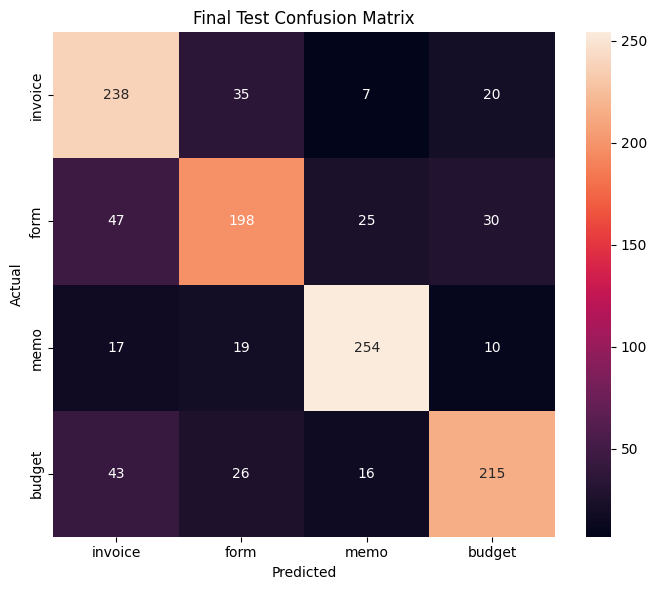

In [17]:
model.load_state_dict(
    torch.load(
        "best_document_cnn.pth",
        map_location=device
    )
)

model = model.to(device)
model.eval()

print("Best model loaded successfully.")

all_labels = []
all_predictions = []

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        outputs = model(images)

        predictions = outputs.argmax(dim=1)

        all_labels.extend(
            labels.cpu().numpy()
        )

        all_predictions.extend(
            predictions.cpu().numpy()
        )

all_labels = np.array(all_labels)
all_predictions = np.array(all_predictions)

# TEST ACCURACY

test_accuracy = accuracy_score(
    all_labels,
    all_predictions
)

print("\n" + "=" * 70)
print("FINAL TEST RESULT")
print("=" * 70)

print(
    f"Test Accuracy: {test_accuracy:.4f}"
)

print(
    f"Test Accuracy: {test_accuracy * 100:.2f}%"
)

# CONFUSION MATRIX

cm = confusion_matrix(
    all_labels,
    all_predictions
)

print("\nConfusion Matrix:")
print(cm)

# CLASSIFICATION REPORT

print("\nClassification Report:")

print(
    classification_report(
        all_labels,
        all_predictions,
        target_names=classes,
        digits=4
    )
)

# CONFUSION MATRIX VISUALIZATION

plt.figure(figsize=(7, 6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=classes,
    yticklabels=classes
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Final Test Confusion Matrix")

plt.tight_layout()
plt.show()